# Week 05 : NLP Architectures

## Seq2Seq → Attention → Transformer → BERT → GPT-2

### 실습 목표
1. **Seq2Seq를 직접 학습**시키고 번역 결과를 확인
2. **Attention을 추가**했을 때 왜 더 좋은지 확인
3. **Self-Attention / Multi-Head Attention** 계산 직접 구현
4. **Transformer Encoder**를 간단한 문장 분류에 학습
5. **BERT / GPT-2**는 사전학습 모델을 사용하되, 단순 호출이 아니라 **loss/예측 원리** 파악

### 실습 흐름
- Part 1. Seq2Seq
- Part 2. Attention Seq2Seq + attention map
- Part 3. Self-Attention / Multi-Head Attention
- Part 4. Transformer Encoder
- Part 5. BERT
- Part 6. GPT-2

### 0. Setup

In [1]:
!pip -q install transformers sentencepiece accelerate

In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import Counter
from transformers import pipeline, AutoTokenizer, AutoModelForMaskedLM, AutoModelForCausalLM, set_seed

SEED = 401
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Part 1. Seq2Seq
번역 데이터에 대해 **실제로 학습**

- 학습이 진행되면서 **loss가 감소**하는지 보기
- 학습 후 **입력 문장에 대해 번역 결과가 나오는지** 보기

In [4]:
pairs = [
    ("i love nlp", "나는 NLP를 좋아해"),
    ("i love you", "나는 너를 좋아해"),
    ("you love nlp", "너는 NLP를 좋아해"),
    ("you love me", "너는 나를 좋아해"),
    ("i like coffee", "나는 커피를 좋아해"),
    ("you like coffee", "너는 커피를 좋아해"),
    ("i like music", "나는 음악을 좋아해"),
    ("you like music", "너는 음악을 좋아해"),
]

print("학습 데이터 개수:", len(pairs))

학습 데이터 개수: 8


In [5]:
special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]

def tokenize_en(s):
    return s.lower().split()

def tokenize_ko(s):
    return s.split()

src_counter = Counter()
tgt_counter = Counter()
for src, tgt in pairs:
    src_counter.update(tokenize_en(src))
    tgt_counter.update(tokenize_ko(tgt))

src_vocab = {tok:i for i, tok in enumerate(special_tokens)}
for tok in src_counter:
    src_vocab[tok] = len(src_vocab)

tgt_vocab = {tok:i for i, tok in enumerate(special_tokens)}
for tok in tgt_counter:
    tgt_vocab[tok] = len(tgt_vocab)

src_itos = {i:t for t, i in src_vocab.items()}
tgt_itos = {i:t for t, i in tgt_vocab.items()}

print("src_vocab:", src_vocab)
print("tgt_vocab:", tgt_vocab)

src_vocab: {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, 'i': 4, 'love': 5, 'nlp': 6, 'you': 7, 'me': 8, 'like': 9, 'coffee': 10, 'music': 11}
tgt_vocab: {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, '나는': 4, 'NLP를': 5, '좋아해': 6, '너를': 7, '너는': 8, '나를': 9, '커피를': 10, '음악을': 11}


In [6]:
def encode_src(text):
    tokens = tokenize_en(text) + ["<eos>"]
    return [src_vocab.get(tok, src_vocab["<unk>"]) for tok in tokens]

def encode_tgt_input(text):
    tokens = ["<sos>"] + tokenize_ko(text)
    return [tgt_vocab.get(tok, tgt_vocab["<unk>"]) for tok in tokens]

def encode_tgt_output(text):
    tokens = tokenize_ko(text) + ["<eos>"]
    return [tgt_vocab.get(tok, tgt_vocab["<unk>"]) for tok in tokens]

encoded_pairs = []
for src, tgt in pairs:
    encoded_pairs.append((encode_src(src), encode_tgt_input(tgt), encode_tgt_output(tgt)))

max_src_len = max(len(x[0]) for x in encoded_pairs)
max_tgt_len = max(len(x[1]) for x in encoded_pairs)

print("max_src_len:", max_src_len)
print("max_tgt_len:", max_tgt_len)

max_src_len: 4
max_tgt_len: 4


In [7]:
def pad_sequence(seq, max_len, pad_id):
    return seq + [pad_id] * (max_len - len(seq))

src_tensor = torch.tensor([pad_sequence(x[0], max_src_len, src_vocab["<pad>"]) for x in encoded_pairs], dtype=torch.long)
tgt_in_tensor = torch.tensor([pad_sequence(x[1], max_tgt_len, tgt_vocab["<pad>"]) for x in encoded_pairs], dtype=torch.long)
tgt_out_tensor = torch.tensor([pad_sequence(x[2], max_tgt_len, tgt_vocab["<pad>"]) for x in encoded_pairs], dtype=torch.long)

print("src_tensor shape:", src_tensor.shape)
print("tgt_in_tensor shape:", tgt_in_tensor.shape)
print("tgt_out_tensor shape:", tgt_out_tensor.shape)

src_tensor shape: torch.Size([8, 4])
tgt_in_tensor shape: torch.Size([8, 4])
tgt_out_tensor shape: torch.Size([8, 4])


In [8]:
# [문제]

class EncoderPractice(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx = 0)   # 정답: nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first = True)         # 정답: nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, hidden = self.rnn(emb)
        return outputs, hidden


class DecoderPractice(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx = 0)   # 정답: nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)         # 정답: nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)          # 정답: nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        emb = self.embedding(x)
        outputs, hidden = self.rnn(emb, hidden)
        logits = self.fc(outputs)
        return logits, hidden

In [9]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, hidden = self.rnn(emb)
        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        emb = self.embedding(x)
        outputs, hidden = self.rnn(emb, hidden)
        logits = self.fc(outputs)
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embed_dim, hidden_dim)
        self.decoder = Decoder(tgt_vocab_size, embed_dim, hidden_dim)

    def forward(self, src, tgt_input):
        _, hidden = self.encoder(src)
        logits, _ = self.decoder(tgt_input, hidden)
        return logits

In [11]:
model = Seq2Seq(len(src_vocab), len(tgt_vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

src_train = src_tensor.to(device)
tgt_in_train = tgt_in_tensor.to(device)
tgt_out_train = tgt_out_tensor.to(device)

losses = []

for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    logits = model(src_train, tgt_in_train)
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out_train.reshape(-1))
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

Epoch  50 | Loss: 0.0014
Epoch 100 | Loss: 0.0007
Epoch 150 | Loss: 0.0005
Epoch 200 | Loss: 0.0003
Epoch 250 | Loss: 0.0003
Epoch 300 | Loss: 0.0002


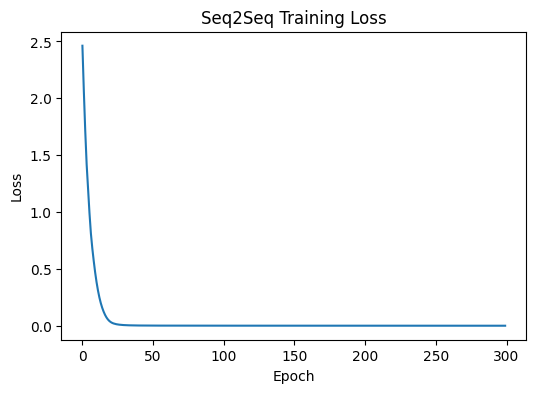

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Seq2Seq Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [13]:
def greedy_decode_seq2seq(model, src_sentence, max_len=10):
    model.eval()
    src_ids = encode_src(src_sentence)
    src_ids = pad_sequence(src_ids, max_src_len, src_vocab["<pad>"])
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        _, hidden = model.encoder(src)

        cur_token = torch.tensor([[tgt_vocab["<sos>"]]], dtype=torch.long).to(device)
        generated = []

        for _ in range(max_len):
            logits, hidden = model.decoder(cur_token, hidden)
            next_id = logits[:, -1, :].argmax(dim=-1).item()
            if next_id == tgt_vocab["<eos>"]:
                break
            generated.append(tgt_itos[next_id])
            cur_token = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return " ".join(generated)

test_sentences = ["i love nlp", "you like music", "i like coffee"]
for s in test_sentences:
    print(f"{s} -> {greedy_decode_seq2seq(model, s)}")

i love nlp -> 나는 NLP를 좋아해
you like music -> 너는 음악을 좋아해
i like coffee -> 나는 커피를 좋아해


## Part 2. Seq2Seq with Attention
이제 Seq2Seq에 Attention을 붙입니다.  

- loss가 더 잘 내려가는지 보기
- decoder가 어느 입력 토큰을 보는지 **attention map** 으로 보기

In [14]:
# [문제]

class AdditiveAttentionPractice(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.Wq = nn.Linear(hidden_dim, hidden_dim)   # 정답: nn.Linear(hidden_dim, hidden_dim)
        self.Wk = nn.Linear(hidden_dim, hidden_dim)   # 정답: nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)    # 정답: nn.Linear(hidden_dim, 1)

    def forward(self, query, keys, mask=None):
        q = self.Wq(query).unsqueeze(1)
        k = self.Wk(keys)
        energy = torch.tanh(q + k)
        scores = self.v(energy).squeeze(-1)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(scores, dim=-1)   # 정답: torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights

In [15]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.Wq = nn.Linear(hidden_dim, hidden_dim)
        self.Wk = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys, mask=None):
        q = self.Wq(query).unsqueeze(1)
        k = self.Wk(keys)
        energy = torch.tanh(q + k)
        scores = self.v(energy).squeeze(-1)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights


class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attn = AdditiveAttention(hidden_dim)
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward_step(self, x_t, hidden, encoder_outputs, src_mask=None):
        emb = self.embedding(x_t).squeeze(1)                  # (batch, embed_dim)
        query = hidden[-1]                                   # (batch, hidden_dim)
        context, weights = self.attn(query, encoder_outputs, src_mask)

        rnn_input = torch.cat([emb, context], dim=-1).unsqueeze(1)
        output, hidden = self.rnn(rnn_input, hidden)
        logits = self.fc(output)
        return logits, hidden, weights


class AttentionSeq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embed_dim, hidden_dim)
        self.decoder = AttentionDecoder(tgt_vocab_size, embed_dim, hidden_dim)

    def forward(self, src, tgt_input):
        encoder_outputs, hidden = self.encoder(src)
        src_mask = (src != src_vocab["<pad>"]).long()

        logits_list = []
        attn_list = []

        for t in range(tgt_input.size(1)):
            x_t = tgt_input[:, t].unsqueeze(1)
            logits, hidden, weights = self.decoder.forward_step(x_t, hidden, encoder_outputs, src_mask)
            logits_list.append(logits)
            attn_list.append(weights)

        logits = torch.cat(logits_list, dim=1)
        attn_weights = torch.stack(attn_list, dim=1)  # (batch, tgt_len, src_len)
        return logits, attn_weights

In [16]:
attn_model = AttentionSeq2Seq(len(src_vocab), len(tgt_vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
optimizer = torch.optim.Adam(attn_model.parameters(), lr=0.01)

attn_losses = []

for epoch in range(300):
    attn_model.train()
    optimizer.zero_grad()

    logits, attn_weights = attn_model(src_train, tgt_in_train)
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out_train.reshape(-1))
    loss.backward()
    optimizer.step()

    attn_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

Epoch  50 | Loss: 0.0011
Epoch 100 | Loss: 0.0005
Epoch 150 | Loss: 0.0003
Epoch 200 | Loss: 0.0003
Epoch 250 | Loss: 0.0002
Epoch 300 | Loss: 0.0002


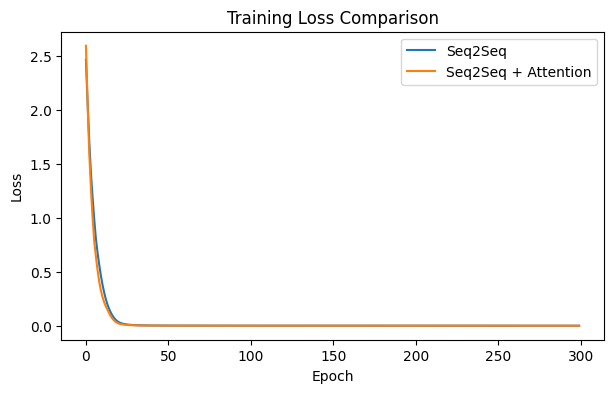

In [17]:
plt.figure(figsize=(7,4))
plt.plot(losses, label="Seq2Seq")
plt.plot(attn_losses, label="Seq2Seq + Attention")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
def greedy_decode_attention(model, src_sentence, max_len=10):
    model.eval()
    src_ids = encode_src(src_sentence)
    src_ids = pad_sequence(src_ids, max_src_len, src_vocab["<pad>"])
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)
        src_mask = (src != src_vocab["<pad>"]).long()

        cur_token = torch.tensor([[tgt_vocab["<sos>"]]], dtype=torch.long).to(device)
        generated = []
        attn_steps = []

        for _ in range(max_len):
            logits, hidden, weights = model.decoder.forward_step(cur_token, hidden, encoder_outputs, src_mask)
            next_id = logits[:, -1, :].argmax(dim=-1).item()
            attn_steps.append(weights[0].detach().cpu().numpy())

            if next_id == tgt_vocab["<eos>"]:
                break

            generated.append(tgt_itos[next_id])
            cur_token = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return generated, np.stack(attn_steps)

src_sentence = "i love nlp"
generated_tokens, attn_map = greedy_decode_attention(attn_model, src_sentence)
print("입력:", src_sentence)
print("출력:", " ".join(generated_tokens))
print("attention map shape:", attn_map.shape)

입력: i love nlp
출력: 나는 NLP를 좋아해
attention map shape: (4, 4)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

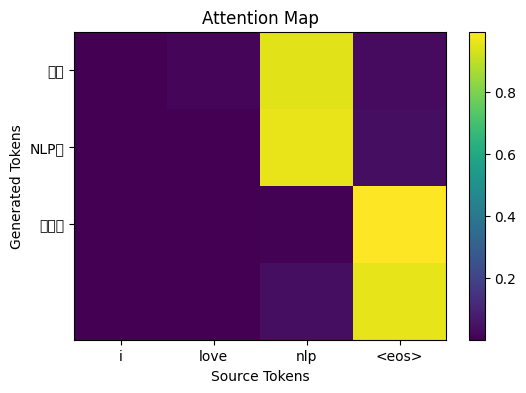

In [19]:
src_labels = tokenize_en(src_sentence) + ["<eos>"]
tgt_labels = generated_tokens

plt.figure(figsize=(6, 4))
plt.imshow(attn_map, aspect="auto")
plt.colorbar()
plt.xticks(range(len(src_labels)), src_labels)
plt.yticks(range(len(tgt_labels)), tgt_labels)
plt.xlabel("Source Tokens")
plt.ylabel("Generated Tokens")
plt.title("Attention Map")
plt.show()

## Part 3. Self-Attention / Multi-Head Attention
이제 RNN 기반이 아니라,  
Transformer에서 핵심인 **Self-Attention** 자체를 확인

In [20]:
x = torch.randn(1, 4, 8).to(device)
print("x shape:", x.shape)

x shape: torch.Size([1, 4, 8])


In [21]:
# [문제]

d_model = 8
W_q = nn.Linear(d_model, d_model).to(device)
W_k = nn.Linear(d_model, d_model).to(device)
W_v = nn.Linear(d_model, d_model).to(device)

Q = W_q(x)   # 정답: W_q(x)
K = W_k(x)   # 정답: W_k(x)
V = W_v(x)   # 정답: W_v(x)

scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model)   # 정답: torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model)
weights = torch.softmax(scores, dim=-1)  # 정답: torch.softmax(scores, dim=-1)
context = torch.matmul(weights, V)  # 정답: torch.matmul(weights, V)

In [22]:
d_model = 8
W_q = nn.Linear(d_model, d_model).to(device)
W_k = nn.Linear(d_model, d_model).to(device)
W_v = nn.Linear(d_model, d_model).to(device)

Q = W_q(x)
K = W_k(x)
V = W_v(x)

scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model)
weights = torch.softmax(scores, dim=-1)
context = torch.matmul(weights, V)

print("scores shape :", scores.shape)
print("weights shape:", weights.shape)
print("context shape:", context.shape)

scores shape : torch.Size([1, 4, 4])
weights shape: torch.Size([1, 4, 4])
context shape: torch.Size([1, 4, 8])


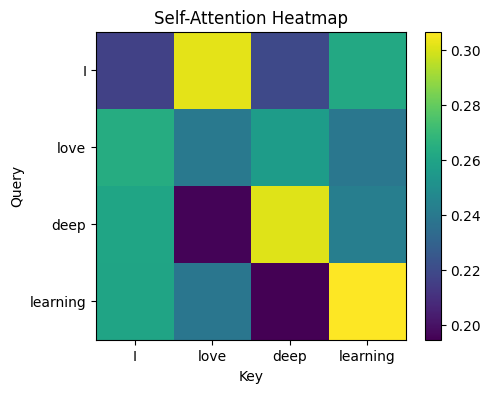

In [24]:
labels = ["I", "love", "deep", "learning"]
weights_np = weights[0].detach().cpu().numpy()

plt.figure(figsize=(5,4))
plt.imshow(weights_np, aspect="auto")
plt.colorbar()
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-Attention Heatmap")
plt.show()

In [23]:
# [문제] Multi-Head Attention 생성
mha_practice = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True).to(device)   # 정답: nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True).to(device)

In [25]:
mha = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True).to(device)

mha_input = torch.randn(1, 4, 8).to(device)
mha_output, mha_weights = mha(
    mha_input, mha_input, mha_input,
    need_weights=True,
    average_attn_weights=False
)

print("mha_output shape :", mha_output.shape)
print("mha_weights shape:", mha_weights.shape)  # (batch, heads, tgt_len, src_len)

mha_output shape : torch.Size([1, 4, 8])
mha_weights shape: torch.Size([1, 2, 4, 4])


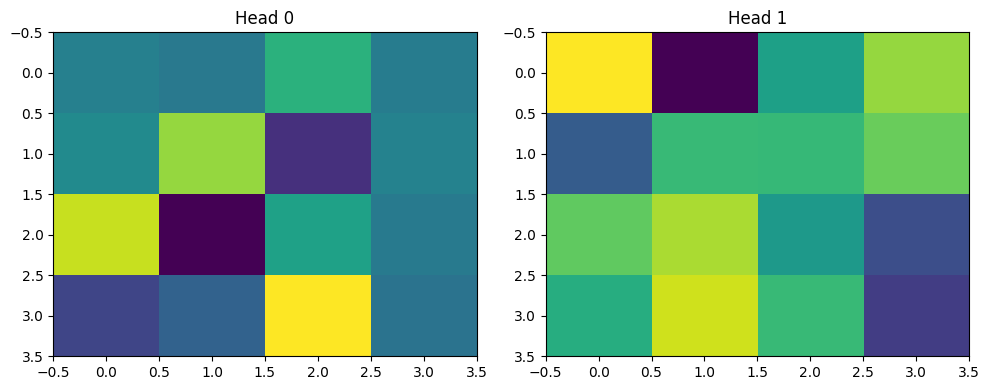

In [26]:
head0 = mha_weights[0, 0].detach().cpu().numpy()
head1 = mha_weights[0, 1].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].imshow(head0, aspect="auto")
axes[0].set_title("Head 0")
axes[1].imshow(head1, aspect="auto")
axes[1].set_title("Head 1")
plt.tight_layout()
plt.show()

## Part 4. Transformer Encoder
이번에는 Transformer Encoder를 이용해 아주 작은 문장 분류를 직접 학습해봅니다.

- 입력 문장을 embedding + positional encoding + transformer encoder에 넣기
- 마지막에 분류기로 sentiment를 예측하기

In [27]:
clf_data = [
    ("i love this movie", 1),
    ("this movie is great", 1),
    ("i like this song", 1),
    ("this book is good", 1),
    ("i hate this movie", 0),
    ("this song is bad", 0),
    ("this book is terrible", 0),
    ("i dislike this class", 0),
]

In [28]:
counter = Counter()
for text, label in clf_data:
    counter.update(text.split())

clf_vocab = {"<pad>":0, "<unk>":1}
for tok in counter:
    clf_vocab[tok] = len(clf_vocab)

clf_itos = {i:t for t,i in clf_vocab.items()}

def encode_clf(text):
    return [clf_vocab.get(tok, clf_vocab["<unk>"]) for tok in text.split()]

max_len = max(len(text.split()) for text, _ in clf_data)

X = torch.tensor([
    encode_clf(text) + [0]*(max_len-len(encode_clf(text)))
    for text, _ in clf_data
], dtype=torch.long)

y = torch.tensor([label for _, label in clf_data], dtype=torch.long)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([8, 4])
y shape: torch.Size([8])


In [29]:
# [문제]

class PositionalEncodingPractice(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)   # 정답: torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)   # 정답: torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [30]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos = PositionalEncoding(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.pos(emb)
        h = self.encoder(emb)
        pooled = h.mean(dim=1)
        logits = self.fc(pooled)
        return logits

In [31]:
clf_model = TinyTransformerClassifier(len(clf_vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clf_model.parameters(), lr=0.01)

X_train = X.to(device)
y_train = y.to(device)

clf_losses = []
for epoch in range(200):
    clf_model.train()
    optimizer.zero_grad()

    logits = clf_model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    clf_losses.append(loss.item())

    if (epoch + 1) % 40 == 0:
        pred = logits.argmax(dim=-1)
        acc = (pred == y_train).float().mean().item()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

Epoch  40 | Loss: 0.0003 | Acc: 1.0000
Epoch  80 | Loss: 0.0002 | Acc: 1.0000
Epoch 120 | Loss: 0.0001 | Acc: 1.0000
Epoch 160 | Loss: 0.0001 | Acc: 1.0000
Epoch 200 | Loss: 0.0001 | Acc: 1.0000


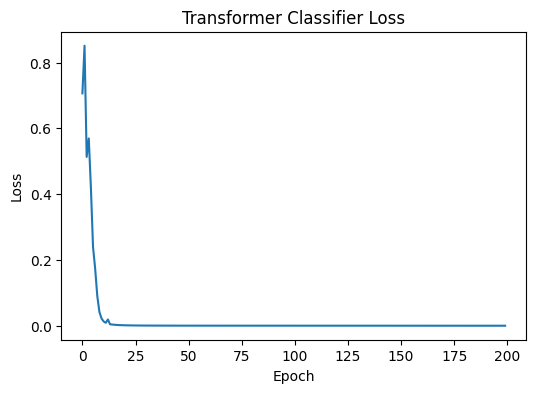

In [32]:
plt.figure(figsize=(6,4))
plt.plot(clf_losses)
plt.title("Transformer Classifier Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [33]:
def predict_sentiment(text):
    clf_model.eval()
    ids = encode_clf(text)
    ids = ids + [0]*(max_len-len(ids))
    x = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = clf_model(x)
        pred = logits.argmax(dim=-1).item()
    return "positive" if pred == 1 else "negative"

tests = [
    "i love this book",
    "this movie is bad",
    "i like this class",
    "this song is terrible"
]

for t in tests:
    print(f"{t} -> {predict_sentiment(t)}")

i love this book -> positive
this movie is bad -> negative
i like this class -> negative
this song is terrible -> negative


## Part 5. BERT
1. `[MASK]` 예측
2. 실제로 특정 정답 토큰에 대한 **loss** 계산


In [34]:
bert_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
fill_mask = pipeline(
    "fill-mask",
    model=bert_name,
    device=0 if torch.cuda.is_available() else -1
)

sentence = "Paris is the [MASK] of France."
result = fill_mask(sentence)

print("입력 문장:", sentence)
for i, r in enumerate(result, 1):
    print(f"{i}. {r['sequence']} (score={r['score']:.4f})")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


입력 문장: Paris is the [MASK] of France.
1. paris is the capital of france. (score=0.9969)
2. paris is the heart of france. (score=0.0006)
3. paris is the center of france. (score=0.0004)
4. paris is the centre of france. (score=0.0003)
5. paris is the city of france. (score=0.0003)


In [36]:
# [문제] BERT pipeline task 이름
bert_task = "fill-mask"   # 정답: fill-mask

In [37]:
# BERT의 masked LM loss 직접 계산
text = "Paris is the [MASK] of France."
inputs = bert_tokenizer(text, return_tensors="pt").to(device)

labels = inputs["input_ids"].clone()
mask_token_id = bert_tokenizer.mask_token_id

# mask가 아닌 위치는 loss 계산 제외
labels[labels != mask_token_id] = -100

# 정답은 capital
mask_pos = (inputs["input_ids"] == mask_token_id).nonzero(as_tuple=False)
capital_id = bert_tokenizer.convert_tokens_to_ids("capital")
labels[mask_pos[:,0], mask_pos[:,1]] = capital_id

with torch.no_grad():
    outputs = bert_model(**inputs, labels=labels)
    print("Masked LM loss:", round(outputs.loss.item(), 4))

Masked LM loss: 0.0031


## Part 6. GPT-2
1. prompt를 주고 **생성 결과** 보기
2. 특정 문장에 대해 **next-token prediction loss** 계산하기

In [38]:
gpt_name = "gpt2"
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name).to(device)

if gpt_tokenizer.pad_token is None:
    gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [39]:
generator = pipeline(
    "text-generation",
    model=gpt_name,
    device=0 if torch.cuda.is_available() else -1
)

prompt = "Deep learning is"
outputs = generator(
    prompt,
    max_length=25,
    num_return_sequences=2,
    do_sample=True,
    temperature=0.8
)

for i, out in enumerate(outputs, 1):
    print(f"[생성 결과 {i}]")
    print(out["generated_text"])
    print()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'temperature', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=25) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[생성 결과 1]
Deep learning is a field that has recently seen some great progress. We're currently in the first phase of a comprehensive review of its efficacy in developing AI in order to determine its potential to scale in the future."

"I can't wait to see the results of this research and have fun tinkering with it to design systems based on it," Gudmundsson said.

Watch the video in its entirety above. Google's DeepMind is a team of researchers working on Deep Neural Networks (DES) that will work in tandem with Google to develop the technology. And as Gudmundsson notes, this research will be in collaboration with Google's AI team to create a future where there is a greater flexibility in the way AI is built.

The Neural Network, which is designed to be able to understand the world at an ever-increasing level, is the first of its kind in the world for which deep learning has yet to be demonstrated. It is believed to be the first ever to be built fully in software and has already been te

In [40]:
# [문제] GPT-2 pipeline task 이름
gpt_task = "text-generation"   # 정답: text-generation

In [41]:
# GPT-2의 causal LM loss 직접 계산
text = "Deep learning is changing the world."
inputs = gpt_tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = gpt_model(**inputs, labels=inputs["input_ids"])
    print("Causal LM loss:", round(outputs.loss.item(), 4))

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Causal LM loss: 3.519
